In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv('../../../Data/ushape.csv')

In [22]:
df.head()

,3.159499363321345566e-02,9.869877579082642072e-01,0.000000000000000000e+00
0,2.115098,-0.046244,1.0
1,0.882490,-0.075756,0.0
2,-0.055144,-0.037332,1.0
3,0.829545,-0.539321,1.0
4,2.112857,0.662084,1.0


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   3.159499363321345566e-02  99 non-null     float64
 1   9.869877579082642072e-01  99 non-null     float64
 2   0.000000000000000000e+00  99 non-null     float64
dtypes: float64(3)
memory usage: 2.4 KB


In [24]:
df.rename(columns={'3.159499363321345566e-02': 'X'}, inplace=True)
df.rename(columns={'9.869877579082642072e-01': 'Y'}, inplace=True)
df.rename(columns={'0.000000000000000000e+00': 'class'}, inplace=True)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       99 non-null     float64
 1   Y       99 non-null     float64
 2   class   99 non-null     float64
dtypes: float64(3)
memory usage: 2.4 KB


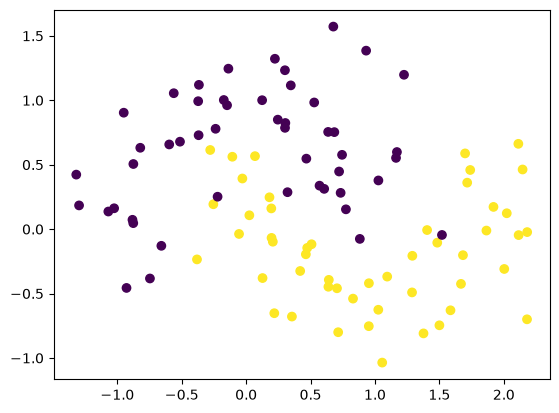

In [26]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [27]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [28]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Input

In [29]:
model = Sequential()

model.add(Input(shape=(2,)))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(10, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.get_weights()

[array([[-0.65620685, -0.26983154,  0.6393077 ,  0.6337164 ,  0.16919142,
         -0.52008724,  0.48624855,  0.6500003 , -0.31038117,  0.6073398 ],
        [ 0.4716192 ,  0.63184696, -0.09205902,  0.1979742 ,  0.49151784,
         -0.12154782, -0.03399175,  0.24156803,  0.4059078 , -0.02533364]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.08801201,  0.04750961, -0.14031547,  0.43502396,  0.11869794,
         -0.00883698, -0.22648802,  0.03403693,  0.4368313 ,  0.53952813],
        [ 0.04117405, -0.31217152, -0.44493723, -0.18275854, -0.2666282 ,
         -0.13108242,  0.49994612,  0.35619903, -0.0912596 , -0.26847234],
        [-0.21381259,  0.14405406,  0.3909791 , -0.13848019,  0.13624781,
          0.06094635, -0.15763146,  0.5175477 , -0.3220749 , -0.48640534],
        [ 0.14090365,  0.06572717, -0.04083699, -0.2827744 ,  0.29244983,
          0.45794606, -0.24169034,  0.17703426, -0.45045048,  0.405546  ],
        [-0.44493

In [31]:
initial_weights = model.get_weights()

In [32]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [33]:
model.set_weights(initial_weights)

In [34]:
model.get_weights()

[array([[ 0.37653974,  1.3215061 ,  0.5221509 , -0.09533617, -0.9164443 ,
          0.15066001, -0.73284084, -0.37964502,  0.46518335, -1.7493293 ],
        [-0.421268  , -0.5433038 ,  0.9592779 , -0.26064968,  0.3847374 ,
         -0.01404596,  0.68468904, -0.25167838,  0.72918415, -0.6591402 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.03083998, -0.10028822,  0.00735901,  0.5575765 ,  0.07909014,
          0.8394153 , -0.5699077 ,  0.20911272, -0.23499668,  0.22615686],
        [-0.27590272,  0.17972732,  0.11734474,  0.36597538, -0.22123094,
          0.41724774,  0.82994086, -0.15203331, -0.45546678, -0.17288941],
        [ 0.09249412, -0.3783191 , -0.01260923,  0.46785805,  0.10737463,
         -0.30954832,  0.34314662, -0.36426026, -0.02556003, -0.00703101],
        [-0.74895406, -0.5519532 , -0.05599928, -0.6114552 , -0.3132469 ,
         -0.03318691, -0.41058528, -0.34909046, -0.36592263, -0.02957246],
        [-0.19994

In [35]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [36]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5823 - loss: 0.6858 - val_accuracy: 0.7500 - val_loss: 0.6314
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5823 - loss: 0.6785 - val_accuracy: 0.8000 - val_loss: 0.6207
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6076 - loss: 0.6717 - val_accuracy: 0.8000 - val_loss: 0.6107
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6329 - loss: 0.6651 - val_accuracy: 0.8000 - val_loss: 0.6010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6329 - loss: 0.6591 - val_accuracy: 0.8000 - val_loss: 0.5926
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6329 - loss: 0.6530 - val_accuracy: 0.8000 - val_loss: 0.5833
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6329 - loss: 0.6471 - val_accuracy: 0.8000 - val_loss: 0.5744
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6456 - loss: 0.6411 - val_accuracy: 0.8500 - val_loss:

In [37]:
model.get_weights()

[array([[ 0.30592728,  1.1282225 ,  0.48827684, -0.24557081, -0.6983323 ,
          0.16428606, -0.56372863, -0.43586826,  0.36508784, -1.813484  ],
        [-0.51575816, -0.6423772 ,  1.085357  , -0.13915117,  0.53562003,
         -0.15167956,  0.8528706 , -0.21167606,  0.77457213, -0.61997753]],
       dtype=float32),
 array([-0.1013134 ,  0.16003801,  0.01065432,  0.20250541, -0.03918003,
         0.04459675,  0.14511675, -0.15107135,  0.13238725,  0.24840206],
       dtype=float32),
 array([[-0.0695892 ,  0.07420104,  0.15931022,  0.68321306, -0.07143965,
          0.95451087, -0.5864331 ,  0.19334236, -0.19979155,  0.37231645],
        [-0.28810138,  0.26583546,  0.19295815,  0.36253852, -0.2319635 ,
          0.25191748,  0.8583824 , -0.19926944, -0.47821036, -0.05545437],
        [ 0.18780594, -0.4990704 , -0.12097395,  0.3180511 ,  0.2504841 ,
         -0.44240582,  0.34690565, -0.35402924, -0.02455749, -0.05499494],
        [-0.9388852 , -0.524407  ,  0.01852909, -0.45441073, 

<Axes: >

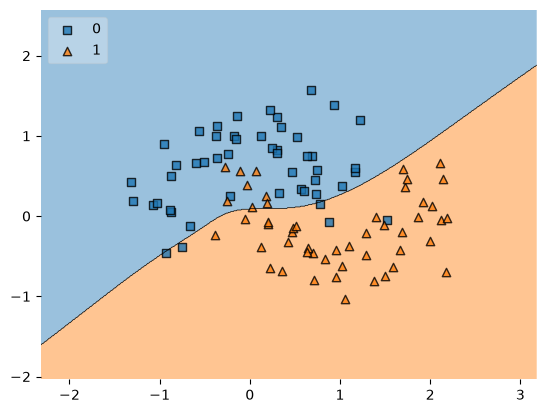

In [38]:
from mlxtend.plotting import plot_decision_regions

class KerasBinaryClassifier:
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold

    def predict(self, X):
        probabilities = self.model.predict(X, verbose=0)
        return (probabilities.ravel() >= self.threshold).astype(int)

plot_decision_regions(X, y.astype(int), clf=KerasBinaryClassifier(model), legend=2)